In [2]:
import pandas as pd 
import numpy as np

In [3]:
df_log=pd.read_csv(r"C:\Data Science Learning\Projects\regression-for-menstrual-pain\dataset\Period_Log.csv")
df_user=pd.read_csv(r"C:\Data Science Learning\Projects\regression-for-menstrual-pain\dataset\User_Profile.csv")

In [4]:
df_log.head() 

,user_id,cycle_number,start_date,cycle_length_days,prev_cycle_length,cycle_phase,flow_level,pain_level,pms_symptoms,mood_score,...,sleep_hours_cycle,energy_level,concentration_score,work_hours_lost,estrogen_pgml,progesterone_ngml,ovulation_result,overall_health_score,log_consistency_score,prepared_before_period
0,U00001,1,2/13/2024,33,NaN,Luteal,Heavy,9,Yes,6,...,5.3,6,7,5.1,84.7,4.14,Positive,6.5,0.949,0
1,U00001,2,3/17/2024,33,33.0,Follicular,Light,2,No,8,...,4.6,7,8,2.6,126.1,2.79,Negative,9.4,0.949,1
2,U00001,3,4/19/2024,34,33.0,Follicular,Heavy,8,No,5,...,5.1,5,5,6.8,131.1,1.70,Negative,6.7,0.949,1
3,U00001,4,5/23/2024,31,34.0,Luteal,Light,3,No,8,...,6.7,8,8,2.5,82.0,8.50,Negative,9.0,0.949,0
4,U00001,5,6/23/2024,31,31.0,Luteal,Moderate,3,No,9,...,5.8,9,8,2.4,55.5,6.30,Negative,9.3,0.949,1


In [5]:
df_user.head()

,user_id,state,age,bmi,diet_quality,exercise_frequency,sleep_hours,caffeine_intake,water_intake_liters,alcohol_consumption,smoking_status,birth_control_use,pcos_diagnosed,stress_score_baseline
0,U00001,Rhode Island,34,26.0,Good,5–6 days/week,5.4,1.5,2.0,Occasionally,No,1,1,4.1
1,U00002,New Hampshire,32,26.6,Good,5–6 days/week,5.5,2.9,2.3,Weekly,No,0,0,5.7
2,U00003,Iowa,18,16.0,Poor,1–2 days/week,6.7,0.5,2.1,Never,No,1,0,3.1
3,U00004,Texas,30,24.7,Excellent,NaN,7.3,0.4,1.8,Occasionally,No,1,0,6.6
4,U00005,Delaware,32,29.2,Good,1–2 days/week,7.1,2.2,2.2,Occasionally,No,0,1,3.1


In [6]:
pd.set_option('display.width', 1000)
pd.set_option('display.max_columns', None)

In [7]:
merged_data = pd.merge(df_log,df_user, on='user_id', how='left')

In [8]:
merged_data.head()

,user_id,cycle_number,start_date,cycle_length_days,prev_cycle_length,cycle_phase,flow_level,pain_level,pms_symptoms,mood_score,stress_score_cycle,sleep_hours_cycle,energy_level,concentration_score,work_hours_lost,estrogen_pgml,progesterone_ngml,ovulation_result,overall_health_score,log_consistency_score,prepared_before_period,state,age,bmi,diet_quality,exercise_frequency,sleep_hours,caffeine_intake,water_intake_liters,alcohol_consumption,smoking_status,birth_control_use,pcos_diagnosed,stress_score_baseline
0,U00001,1,2/13/2024,33,NaN,Luteal,Heavy,9,Yes,6,5.4,5.3,6,7,5.1,84.7,4.14,Positive,6.5,0.949,0,Rhode Island,34,26.0,Good,5–6 days/week,5.4,1.5,2.0,Occasionally,No,1,1,4.1
1,U00001,2,3/17/2024,33,33.0,Follicular,Light,2,No,8,3.7,4.6,7,8,2.6,126.1,2.79,Negative,9.4,0.949,1,Rhode Island,34,26.0,Good,5–6 days/week,5.4,1.5,2.0,Occasionally,No,1,1,4.1
2,U00001,3,4/19/2024,34,33.0,Follicular,Heavy,8,No,5,5.7,5.1,5,5,6.8,131.1,1.70,Negative,6.7,0.949,1,Rhode Island,34,26.0,Good,5–6 days/week,5.4,1.5,2.0,Occasionally,No,1,1,4.1
3,U00001,4,5/23/2024,31,34.0,Luteal,Light,3,No,8,5.2,6.7,8,8,2.5,82.0,8.50,Negative,9.0,0.949,0,Rhode Island,34,26.0,Good,5–6 days/week,5.4,1.5,2.0,Occasionally,No,1,1,4.1
4,U00001,5,6/23/2024,31,31.0,Luteal,Moderate,3,No,9,3.7,5.8,9,8,2.4,55.5,6.30,Negative,9.3,0.949,1,Rhode Island,34,26.0,Good,5–6 days/week,5.4,1.5,2.0,Occasionally,No,1,1,4.1


In [9]:
merged_data.dropna(inplace=True)

In [10]:
merged_data.columns

Index(['user_id', 'cycle_number', 'start_date', 'cycle_length_days', 'prev_cycle_length', 'cycle_phase', 'flow_level', 'pain_level', 'pms_symptoms', 'mood_score', 'stress_score_cycle', 'sleep_hours_cycle', 'energy_level', 'concentration_score', 'work_hours_lost', 'estrogen_pgml', 'progesterone_ngml', 'ovulation_result', 'overall_health_score', 'log_consistency_score', 'prepared_before_period', 'state', 'age', 'bmi', 'diet_quality', 'exercise_frequency', 'sleep_hours', 'caffeine_intake', 'water_intake_liters', 'alcohol_consumption', 'smoking_status', 'birth_control_use', 'pcos_diagnosed', 'stress_score_baseline'], dtype='object')

In [11]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

In [12]:
encoding_columns=["cycle_phase","pms_symptoms","ovulation_result"]

In [13]:
encoder = ColumnTransformer(transformers=[
    ('ohe', OneHotEncoder(sparse_output=False,drop="first"), encoding_columns)
], remainder='passthrough') 

In [14]:
encoded_array = encoder.fit_transform(merged_data)

In [15]:
ohe_feature_names = encoder.named_transformers_['ohe'].get_feature_names_out(encoding_columns)
remaining_cols = [col for col in merged_data.columns if col not in encoding_columns]
all_columns = list(ohe_feature_names) + remaining_cols

In [16]:
df_encoded = pd.DataFrame(encoded_array, columns=all_columns)

In [17]:
df_encoded.head()

,cycle_phase_Luteal,cycle_phase_Menstrual,pms_symptoms_Yes,ovulation_result_Positive,user_id,cycle_number,start_date,cycle_length_days,prev_cycle_length,flow_level,pain_level,mood_score,stress_score_cycle,sleep_hours_cycle,energy_level,concentration_score,work_hours_lost,estrogen_pgml,progesterone_ngml,overall_health_score,log_consistency_score,prepared_before_period,state,age,bmi,diet_quality,exercise_frequency,sleep_hours,caffeine_intake,water_intake_liters,alcohol_consumption,smoking_status,birth_control_use,pcos_diagnosed,stress_score_baseline
0,0.0,0.0,0.0,0.0,U00001,2,3/17/2024,33,33.0,Light,2,8,3.7,4.6,7,8,2.6,126.1,2.79,9.4,0.949,1,Rhode Island,34,26.0,Good,5–6 days/week,5.4,1.5,2.0,Occasionally,No,1,1,4.1
1,0.0,0.0,0.0,0.0,U00001,3,4/19/2024,34,33.0,Heavy,8,5,5.7,5.1,5,5,6.8,131.1,1.7,6.7,0.949,1,Rhode Island,34,26.0,Good,5–6 days/week,5.4,1.5,2.0,Occasionally,No,1,1,4.1
2,1.0,0.0,0.0,0.0,U00001,4,5/23/2024,31,34.0,Light,3,8,5.2,6.7,8,8,2.5,82.0,8.5,9.0,0.949,0,Rhode Island,34,26.0,Good,5–6 days/week,5.4,1.5,2.0,Occasionally,No,1,1,4.1
3,1.0,0.0,0.0,0.0,U00001,5,6/23/2024,31,31.0,Moderate,3,9,3.7,5.8,9,8,2.4,55.5,6.3,9.3,0.949,1,Rhode Island,34,26.0,Good,5–6 days/week,5.4,1.5,2.0,Occasionally,No,1,1,4.1
4,1.0,0.0,0.0,0.0,U00001,6,7/24/2024,37,31.0,Moderate,6,6,4.9,4.5,6,7,4.6,107.8,7.17,7.7,0.949,0,Rhode Island,34,26.0,Good,5–6 days/week,5.4,1.5,2.0,Occasionally,No,1,1,4.1


In [18]:
from sklearn.preprocessing import OrdinalEncoder

In [19]:
df_encoded["diet_quality"].unique()

array(['Good', 'Poor', 'Average', 'Excellent'], dtype=object)

In [20]:
ordinal_cols_order = {
    "flow_level":      ["Light", "Moderate", "Heavy"],
    "diet_quality":       ["Poor", "Average", "Good", "Excellent"],
    "alcohol_consumption":  ['Never', 'Occasionally', 'Weekly'],
    "exercise_frequency":[ "1–2 days/week", '3–4 days/week','5–6 days/week']
}

In [21]:
ordinal_cols   = list(ordinal_cols_order.keys())
category_order = list(ordinal_cols_order.values())

In [22]:
encoder = OrdinalEncoder(categories=category_order)
df_encoded[ordinal_cols] = encoder.fit_transform(df_encoded[ordinal_cols])

In [23]:
df_encoded[ordinal_cols].head()

,flow_level,diet_quality,alcohol_consumption,exercise_frequency
0,0.0,2.0,1.0,2.0
1,2.0,2.0,1.0,2.0
2,0.0,2.0,1.0,2.0
3,1.0,2.0,1.0,2.0
4,1.0,2.0,1.0,2.0


In [24]:
df_encoded["smoking_status"]=df_encoded["smoking_status"].map({"No":0,"Yes":1})

In [25]:
df_encoded.head()

,cycle_phase_Luteal,cycle_phase_Menstrual,pms_symptoms_Yes,ovulation_result_Positive,user_id,cycle_number,start_date,cycle_length_days,prev_cycle_length,flow_level,pain_level,mood_score,stress_score_cycle,sleep_hours_cycle,energy_level,concentration_score,work_hours_lost,estrogen_pgml,progesterone_ngml,overall_health_score,log_consistency_score,prepared_before_period,state,age,bmi,diet_quality,exercise_frequency,sleep_hours,caffeine_intake,water_intake_liters,alcohol_consumption,smoking_status,birth_control_use,pcos_diagnosed,stress_score_baseline
0,0.0,0.0,0.0,0.0,U00001,2,3/17/2024,33,33.0,0.0,2,8,3.7,4.6,7,8,2.6,126.1,2.79,9.4,0.949,1,Rhode Island,34,26.0,2.0,2.0,5.4,1.5,2.0,1.0,0,1,1,4.1
1,0.0,0.0,0.0,0.0,U00001,3,4/19/2024,34,33.0,2.0,8,5,5.7,5.1,5,5,6.8,131.1,1.7,6.7,0.949,1,Rhode Island,34,26.0,2.0,2.0,5.4,1.5,2.0,1.0,0,1,1,4.1
2,1.0,0.0,0.0,0.0,U00001,4,5/23/2024,31,34.0,0.0,3,8,5.2,6.7,8,8,2.5,82.0,8.5,9.0,0.949,0,Rhode Island,34,26.0,2.0,2.0,5.4,1.5,2.0,1.0,0,1,1,4.1
3,1.0,0.0,0.0,0.0,U00001,5,6/23/2024,31,31.0,1.0,3,9,3.7,5.8,9,8,2.4,55.5,6.3,9.3,0.949,1,Rhode Island,34,26.0,2.0,2.0,5.4,1.5,2.0,1.0,0,1,1,4.1
4,1.0,0.0,0.0,0.0,U00001,6,7/24/2024,37,31.0,1.0,6,6,4.9,4.5,6,7,4.6,107.8,7.17,7.7,0.949,0,Rhode Island,34,26.0,2.0,2.0,5.4,1.5,2.0,1.0,0,1,1,4.1


In [26]:
df_encoded.columns

Index(['cycle_phase_Luteal', 'cycle_phase_Menstrual', 'pms_symptoms_Yes', 'ovulation_result_Positive', 'user_id', 'cycle_number', 'start_date', 'cycle_length_days', 'prev_cycle_length', 'flow_level', 'pain_level', 'mood_score', 'stress_score_cycle', 'sleep_hours_cycle', 'energy_level', 'concentration_score', 'work_hours_lost', 'estrogen_pgml', 'progesterone_ngml', 'overall_health_score', 'log_consistency_score', 'prepared_before_period', 'state', 'age', 'bmi', 'diet_quality', 'exercise_frequency', 'sleep_hours', 'caffeine_intake', 'water_intake_liters', 'alcohol_consumption', 'smoking_status', 'birth_control_use', 'pcos_diagnosed', 'stress_score_baseline'], dtype='object')

In [27]:
#df_encoded.drop(["cycle_phase","pms_symptoms","ovulation_result"],inplace=True,axis=1)

In [28]:
df_encoded.to_csv(r"C:\Data Science Learning\Projects\regression-for-menstrual-pain\dataset\final_ds.csv",index=False)

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

# Drop non-numeric / irrelevant columns
drop_cols = ['user_id', 'start_date', 'state']
df_numeric = df_encoded.drop(columns=drop_cols)

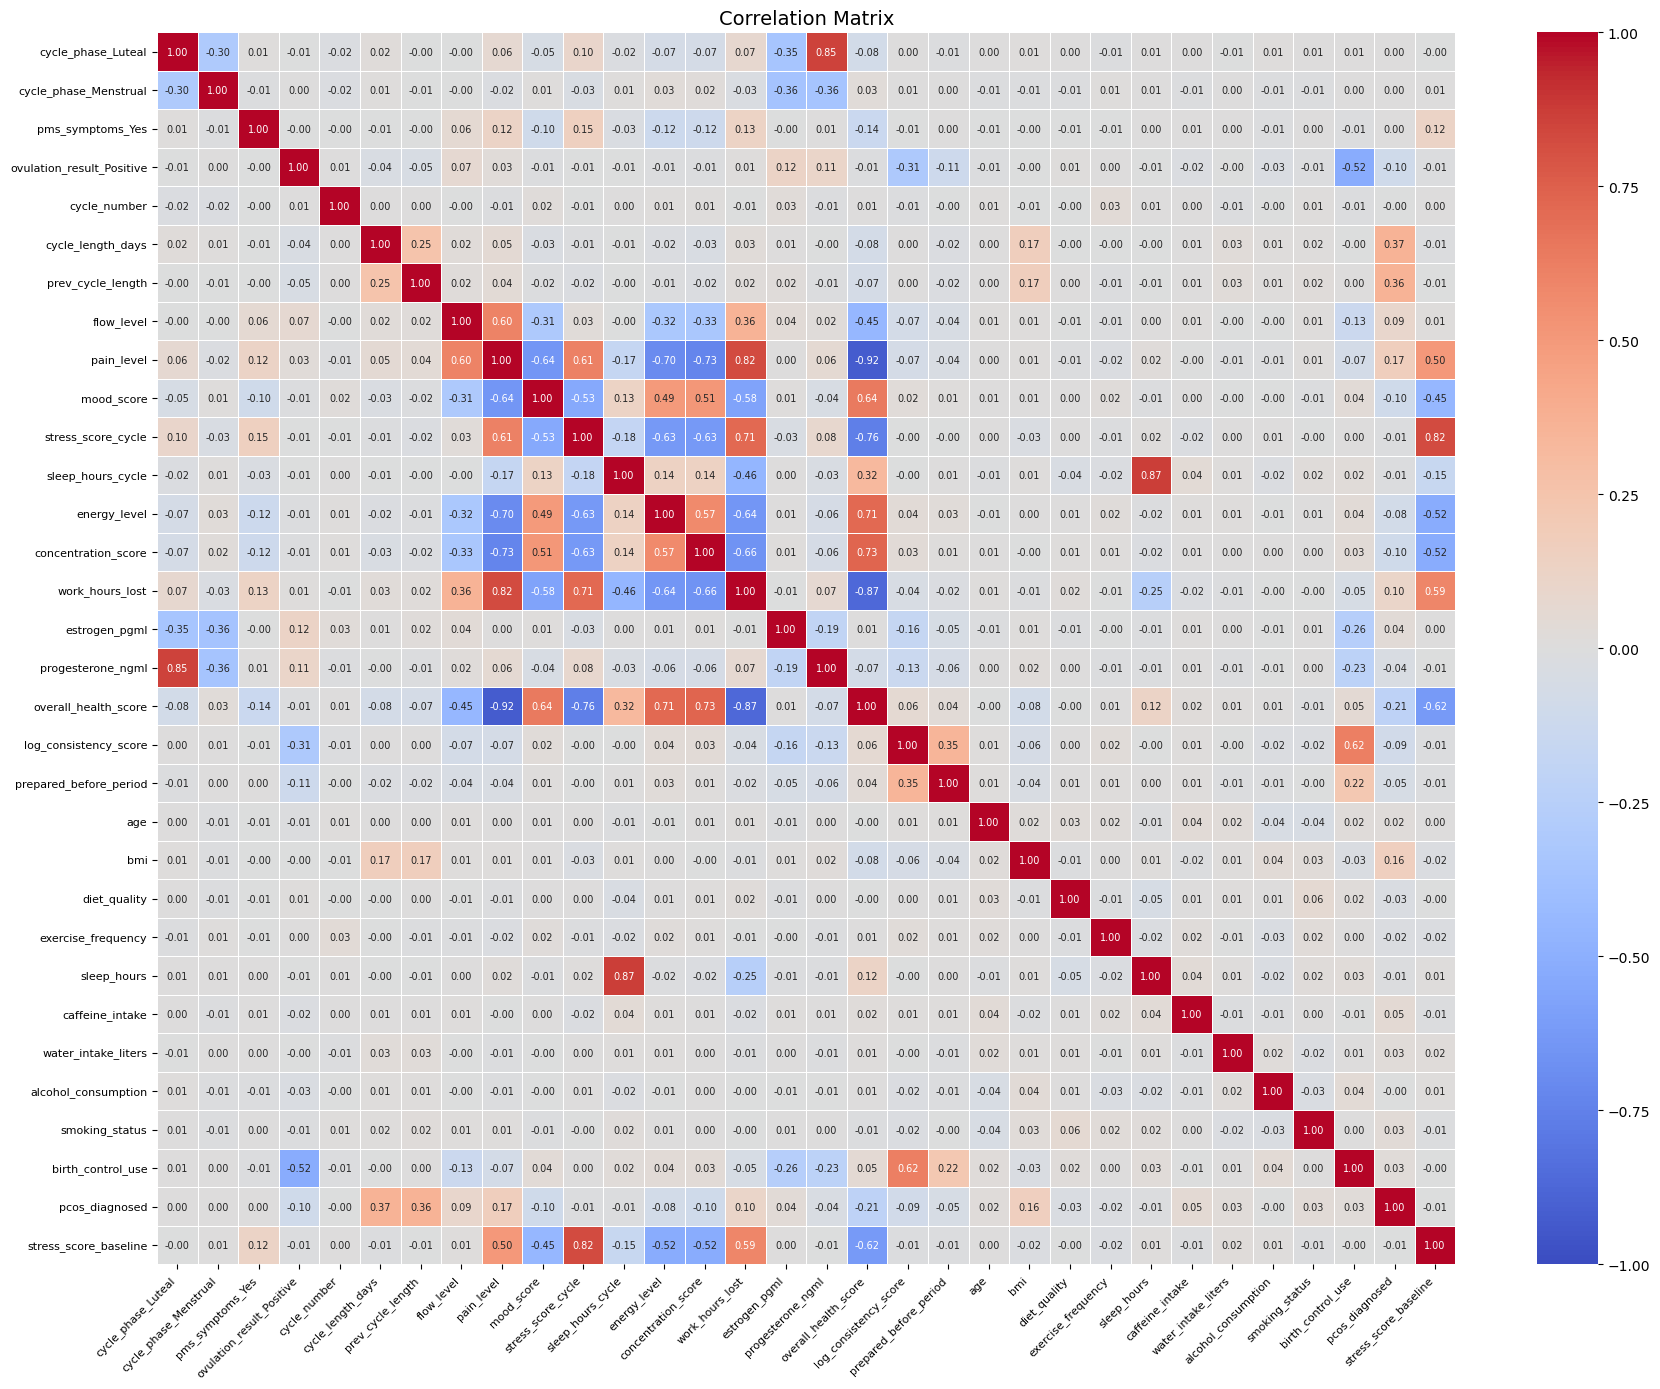

In [30]:
# Correlation Matrix (better for mixed-scale columns like yours)
corr_matrix = df_numeric.corr()

plt.figure(figsize=(18, 14))
sns.heatmap(corr_matrix, annot=True, fmt=".2f",
            cmap="coolwarm", linewidths=0.5,
            annot_kws={"size": 7},
            vmin=-1, vmax=1)          # fixes scale between -1 and 1
plt.title("Correlation Matrix", fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

In [71]:
df_encoded.columns

Index(['cycle_phase_Luteal', 'cycle_phase_Menstrual', 'pms_symptoms_Yes', 'ovulation_result_Positive', 'user_id', 'cycle_number', 'start_date', 'cycle_length_days', 'prev_cycle_length', 'flow_level', 'pain_level', 'mood_score', 'stress_score_cycle', 'sleep_hours_cycle', 'energy_level', 'concentration_score', 'work_hours_lost', 'estrogen_pgml', 'progesterone_ngml', 'overall_health_score', 'log_consistency_score', 'prepared_before_period', 'state', 'age', 'bmi', 'diet_quality', 'exercise_frequency', 'sleep_hours', 'caffeine_intake', 'water_intake_liters', 'alcohol_consumption', 'smoking_status', 'birth_control_use', 'pcos_diagnosed', 'stress_score_baseline'], dtype='object')